In [1]:
import torch
import humanize
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
from IPython.display import clear_output
from IPython import display
from pathlib import Path

def ensure_file(file_path):
  base_path = Path(file_path).parent
  Path(base_path).mkdir(parents=True, exist_ok=True)
  return file_path


def load_dataset(path, cache_file, eos_token):
  def process(line):
    encoded = list(line.encode("utf-8"))
    encoded.append(eos_token)
    return encoded

  try:
    return torch.load(cache_file)
  except:
    sequences = []
    with open(path, "r") as txt_file:
      lines = txt_file.read().split("\n")
      sequences = [process(line) for line in lines if len(line) > 0]

    max_seq_len = max(map(lambda s: len(s), sequences))
    padded = torch.full((len(sequences), max_seq_len), eos_token, dtype=torch.int)
    for i, sequence in enumerate(sequences):
      padded[i, :len(sequence)] = torch.tensor(sequence, dtype=torch.int)

    torch.save(padded, cache_file)
    return padded

In [2]:
def init_linear(dim_in, dim_out):
  layer = nn.Linear(dim_in, dim_out)
  nn.init.kaiming_normal_(layer.weight)
  nn.init.constant_(layer.bias, 0.0)
  return layer


def init_tensor(size, scale, residual_scale=1.0):
  total_scale = scale * residual_scale
  return nn.Parameter(torch.randn(*size) * total_scale)


def custom_learning_rate(step, hp):
  ws, ts = hp["warmup_steps"], hp["train_steps"]

  # Linear warmup phase
  if step < ws:
    return float(step) / float(max(1, ws))

  # Cosine decay phase
  progress = float(step - ws) / float(max(1, ts - ws))
  return 0.5 * (1.0 + math.cos(math.pi * progress))

class Decoder(nn.Module):
  # B x T x E input and output, where B is the batch size, T is the token
  # sequence length and E is the embedding dimension.
  def __init__(self, E, H, D_k, D_f, L):
    super().__init__()
    self.H, self.D_k = H, D_k
    # Because LayerNorm is the first stage of a dcoder block, there needs to be
    # a way to stop variance from exploding as the model gets deeper. Scaling by
    # 1 / sqrt(2 * L), where L is the number of decoder layers and 2 refers to the
    # 2 residual connections present in a decoder layer ensures that the variance
    # remains a constant 2.
    res_scale = 1 / math.sqrt(2.0 * L)
    kaiming_scale = math.sqrt(2.0 / E)
    kaiming_scale_out = math.sqrt(2.0 / (D_k * H))

    # Linear projection matrices for the query, key and value
    # B x T x E -> B x H x T x D_k, where H is the number of attention heads and
    # D_k is the query, key and value embedding dimension for each attention head
    self.Q_proj = init_tensor((E, D_k * H), kaiming_scale)
    self.K_proj = init_tensor((E, D_k * H), kaiming_scale)
    self.V_proj = init_tensor((E, D_k * H), kaiming_scale)
    # Output projection for the scaled values of the concatenated attention heads
    self.O_proj = init_tensor((D_k * H, E), kaiming_scale_out, residual_scale=res_scale)

    self.norm1 = nn.LayerNorm(E) # After the multihead self-attention
    self.norm2 = nn.LayerNorm(E) # After the feed forward network

    # Feed forward network: B x T x E -> B x T x D_f -> B x T x E,
    # where D_f is the dimension of the hidden layer
    self.ffn = nn.Sequential(init_linear(E, D_f), nn.ReLU(), init_linear(D_f, E))

    # Scale the final feed forward layer by the residual scale
    with torch.no_grad():
      self.ffn[2].weight.mul_(res_scale)

  def forward(self, x, M):
    norm_x1 = self.norm1(x)

    # Linearly project queries, keys and value for each attention head, perform
    # multi-head masked self-attention on the input, each concatenate each attention
    # head's values and linearly project them back into embedding space.
    B, T = x.shape[0], x.shape[1]
    Q = (norm_x1 @ self.Q_proj).reshape(B, T, self.H, self.D_k).transpose(1, 2)
    K = (norm_x1 @ self.K_proj).reshape(B, T, self.H, self.D_k).transpose(1, 2)
    V = (norm_x1 @ self.V_proj).reshape(B, T, self.H, self.D_k).transpose(1, 2)

    # The causal mask ensures that future tokens can't be attended to since e^-inf approaches 0.
    scaled = F.scaled_dot_product_attention(Q, K, V, attn_mask=M)
    # Concatenate each attention head and linearly project the result back into embedding space
    attended = scaled.transpose(1, 2).reshape(B, T, self.H * self.D_k) @ self.O_proj

    # Process the attended values
    x = attended + x
    norm_x2 = self.norm2(x)
    return self.ffn(norm_x2) + x


class Transformer(nn.Module):
  # B x T input and B x T x V output, where B is the batch size, T is the token
  # sequence length. Each token is an index into the vocabulary (V).
  def __init__(self, V, E, T, H, D_k, D_f, L):
    super().__init__()
    # Embeddings: B x T -> B x T x E, where E is the embedding dimension
    self.tok_embed = init_tensor((V, E), math.sqrt(2.0 / E))
    self.E_scale = math.sqrt(E)

    # Cached values for rotary positional encoding
    theta = 10000 ** ((-2 * torch.arange(E // 2)) / E)
    theta = torch.repeat_interleave(theta, repeats=2)
    angles = torch.arange(T)[:, None] * theta
    idx = torch.arange(E)

    self.register_buffer("cos_angles", torch.cos(angles))  
    self.register_buffer("sin_angles", torch.sin(angles))  
    self.register_buffer("signs", ((-1) ** torch.arange(1, E + 1)).expand(T, -1))
    self.register_buffer("alt_idx", torch.arange(E) ^ 1)
      
    # Share the same causal mask for all decoders to save memory
    temp = torch.full((T, T), float("-inf"))
    self.register_buffer("causal_mask", torch.triu(temp, diagonal=1))

    # Transformer decoder layers are referred to as decoders because of their
    # auto-regressive masked self-attention, not because of their structure.
    self.layers = nn.ModuleList([Decoder(E, H, D_k, D_f, L) for _ in range(L)])
    self.final_norm = nn.LayerNorm(E)

  def forward(self, x, eos_token):
    # Mask out end of sequence tokens that serve as padding
    idx = (x == eos_token).int().argmax(dim=1)
    positions = torch.arange(x.shape[-1], device=x.device)
    valid_keys = positions[None, :] <= idx[:, None]
    pad_mask = torch.where(valid_keys[:, None, None, :], 0.0, float("-inf"))
    M = self.causal_mask[None, None, :, :] + pad_mask

    # Each token selects a row from the learned token embedding matrix.
    embeddings = self.tok_embed[x] * self.E_scale

    # Rotary position encoding using cached constants
    embeddings = embeddings * self.cos_angles + \
      embeddings[:, :, self.alt_idx] * self.signs * self.sin_angles

    for layer in self.layers:
      embeddings = layer(embeddings, M)
    embeddings = self.final_norm(embeddings)

    # Convert embeddings back into tokens by creating a B x T x V logit matrix. During
    # training, the difference between the actual next token and the most probable next
    # token will be minimized. During inference, the next most probable token will be selected.
    return embeddings @ self.tok_embed.T

In [3]:
# Since the target dataset is so small, character level tokenization is used
hp = {
  "embedding_dim": 256, "num_attn_heads": 8, "attn_dim": 64,
  "ffn_dim": 1024, "seq_len": 64, "num_layers": 12, "batch_size": 64,
  "train_steps": 10000, "warmup_steps": 500, "test_steps": 500,
  "train_split": 0.8, "eos_token": 256, "vocab_size": 257,
  "lr": 3e-4, "betas": (0.9, 0.98), "eps": 1e-8
}

data_cache_file = ensure_file(".data/prepared-dataset.pth")
model_cache_file = ensure_file(".data/model-weights.pth")
dataset_path = ensure_file("/kaggle/input/datasets/abigailadegbiji/karpathy-char-rnn/karpathy-char-rnn-input.txt")
sequences = load_dataset(dataset_path, data_cache_file, hp["eos_token"])
total_rows = sequences.shape[0]
train_split = int(hp["train_split"] * total_rows)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = Transformer(
  hp["vocab_size"], hp["embedding_dim"], hp["seq_len"],
  hp["num_attn_heads"], hp["attn_dim"], hp["ffn_dim"], hp["num_layers"])
model = model.to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Using {device} to train a {humanize.intword(num_params)} parameter model.")

Using cuda to train a 12.7 million parameter model.


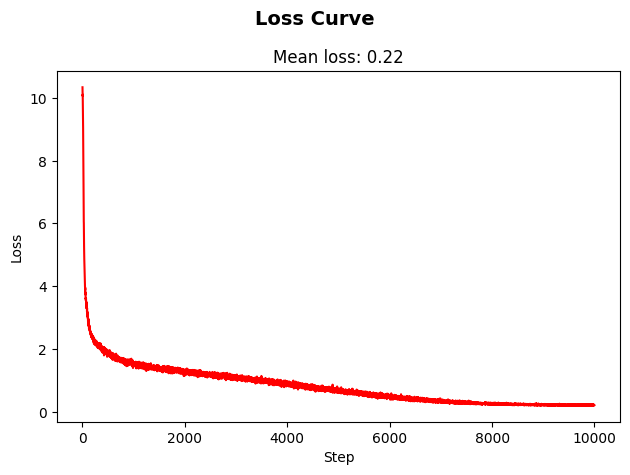

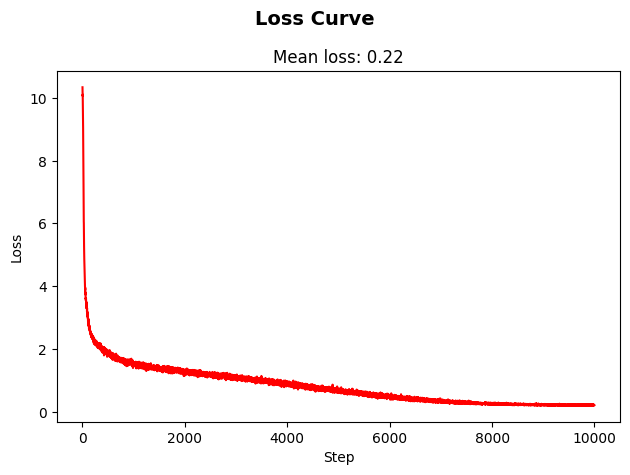

In [4]:
# Training loop
optimizer = AdamW(model.parameters(), lr=hp["lr"], betas=hp["betas"], eps=hp["eps"])
scheduler = LambdaLR(optimizer, lambda x: custom_learning_rate(x, hp))
criterion = nn.CrossEntropyLoss()

fig, ax = plt.subplots()
step_losses = []

with torch.enable_grad():
  model.train()

  for step in range(hp["train_steps"]):
    indices = torch.randint(low=0, high=train_split, size=(hp["batch_size"],))
    rows = sequences[indices].to(device)
    target = rows[:, 1:].long() # The correct next token is the sequence shifted to the left

    with torch.autocast(device_type=device, dtype=torch.bfloat16):
      prediction = model(rows, hp["eos_token"])
      prediction = prediction[:, :-1]

      eos_positions = (rows == hp["eos_token"]).long().argmax(dim=1)
      positions = torch.arange(rows.shape[1] - 1, device=device)
      loss_mask = positions[None, :] < eos_positions[:, None]
      loss = criterion(prediction[loss_mask], target[loss_mask])
    
    step_losses.append(loss.item())
    loss.backward()

    optimizer.step()
    optimizer.zero_grad(set_to_none=True)
    scheduler.step()

    # Plot a loss curve in real time
    clear_output(wait=True)
    ax.clear()
    ax.plot(step_losses, "r-")
    ax.autoscale_view(scalex=True, scaley=True)
    fig.suptitle("Loss Curve", fontsize=14, fontweight="bold")
    ax.set_title(f"Mean loss: {step_losses[-1]:.2f}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")

    fig.tight_layout() # Prevents overlapping labels
    display.display(fig)

  torch.save(model.state_dict(), model_cache_file)
  fig.savefig("plot.png", dpi=300, bbox_inches="tight")

In [5]:
# Test loop
torch.set_grad_enabled(False)
model.eval()

test_losses = []
for _ in range(hp["test_steps"]):
  indices = torch.randint(low=train_split, high=total_rows, size=(hp["batch_size"],))
  rows = sequences[indices].to(device)
  target = rows[:, 1:].long() # The correct next token is the sequence shifted to the left

  with torch.autocast(device_type=device, dtype=torch.bfloat16):
    prediction = model(rows, hp["eos_token"])
    prediction = prediction[:, :-1]

    eos_positions = (rows == hp["eos_token"]).long().argmax(dim=1)
    positions = torch.arange(rows.shape[1] - 1, device=device)
    loss_mask = positions[None, :] < eos_positions[:, None]

    loss = criterion(prediction[loss_mask], target[loss_mask])
    test_losses.append(loss.item())

print("Mean test loss:", sum(test_losses) / len(test_losses))

Mean test loss: 3.546704391002655


In [6]:
# Simple inference demo:
# It's clear that tiny models trained on tiny datasets have very poor performance. The real magic happens at scale.
state_dict = torch.load(model_cache_file, weights_only=True, map_location=torch.device(device))
model.load_state_dict(state_dict)

num_examples = (4, )
rows = sequences[torch.randint(train_split, total_rows, num_examples)]
rows = rows.to(device)
prediction = model(rows, hp["eos_token"])
prediction = torch.softmax(prediction, dim=-1)
sampled = torch.argmax(prediction, dim=-1) # Greedy decoding

eos_mask = rows == hp["eos_token"]
seq_lengths = torch.argmax(eos_mask.to(torch.int32), dim=-1)
has_value = eos_mask.any(dim=-1)
seq_lengths[~has_value] = rows.shape[-1]

def decode_outputs(outputs):
  for seq in outputs:
    values = seq.tolist()
    try:
      last = values.index(hp["eos_token"])
    except:
      last = len(values)
    tokens = bytes(values[:last])
    print(tokens.decode("utf-8"))

print("====Input sequences:====")
length_mask = \
  torch.arange(rows.shape[-1], device=device) < seq_lengths[:, None]
outputs = torch.split(rows[length_mask], seq_lengths.tolist())
decode_outputs(outputs)

print("\n====Next tokens:====")
idx = torch.arange(rows.shape[0])
next_token_ids = sampled[idx, seq_lengths - 1]
decode_outputs(sampled)

torch.set_grad_enabled(True)

====Input sequences:====
This nor hurts him nor profits you a jot;
But who comes here?
And that, by great injunctions, I am bound
Ay, sir.

====Next tokens:====
hes iib sansh ted taw heiuati oou orkuy
ut tha comes here? 
nd thet  tr noaet ss urceicu. 
n, air;


torch.autograd.grad_mode.set_grad_enabled(mode=True)